Réalisé par :**SALIM SEMLALI**

Encadré par :**Pr.Ahmed Drissi El Maliani**

# ABIDE fMRI + Mamba : Modélisation Temporelle des Connectomes cérébraux pour la classification du TSA

Ce notebook couvre :
1. **Téléchargement** des données ABIDE via nilearn
2. **Preprocessing** : Extraction ROI (atlas CC200/AAL), Matrices de connectivité
3. **Architecture Mamba** :Implémentation du modèle Mamba from scratch et adaptation aux séries temporelles fMRI
4. **Entraînement** : Classification ASD vs Control
5. **Évaluation** : Accuracy, AUC, Visualisations
6. **Comparaison Mamba vs LSTM vs Transformer**

## 0. Installation des dépendances

In [ ]:
# Installer les packages nécessaires
!pip install nilearn nibabel scikit-learn matplotlib seaborn tqdm einops torch torchvision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 28.5 MB/s eta 0:00:00


In [ ]:
# Importer les packages nécessaires
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Neuroimaging
import nilearn
from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker

# ML
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"Nilearn version : {nilearn.__version__}")
print(f"PyTorch version : {torch.__version__}")

Device : cpu
Nilearn version : 0.13.1
PyTorch version : 2.11.0+cpu


## 1. Téléchargement des données ABIDE

On utilise le mirror ABIDE-I préprocessé via `nilearn.datasets.fetch_abide_pcp`.
Le pipeline **cpac** avec global signal regression (`gsr`) est standard.

In [ ]:
#Paramètres
DATA_DIR   = './abide_data'
N_SUBJECTS = 653
PIPELINE   = 'cpac'
BAND_PASS  = True
GLOBAL_SIG = True
ATLAS_NAME = 'cc200'


os.makedirs(DATA_DIR, exist_ok=True)

print(f"Téléchargement ABIDE-I ({N_SUBJECTS} sujets, atlas {ATLAS_NAME})...")
abide = datasets.fetch_abide_pcp(
    data_dir=DATA_DIR,
    n_subjects=N_SUBJECTS,
    pipeline=PIPELINE,
    band_pass_filtering=BAND_PASS,
    global_signal_regression=GLOBAL_SIG,
    derivatives=['rois_cc200'],
    quality_checked=True,
    verbose=0
)

print(f"Sujets téléchargés : {len(abide['rois_cc200'])}")
print(f"Colonnes phénotypiques : {list(abide.phenotypic.columns[:10])}")


Téléchargement ABIDE-I (653 sujets, atlas cc200)...
Sujets téléchargés : 653
Colonnes phénotypiques : ['i', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'FILE_ID', 'DX_GROUP', 'DSM_IV_TR', 'AGE_AT_SCAN']


## Analyse exploratoire et descriptive des données phénotypiques du dataset ABIDE-I

Distribution :
label
Control    346
ASD        307
Name: count, dtype: int64


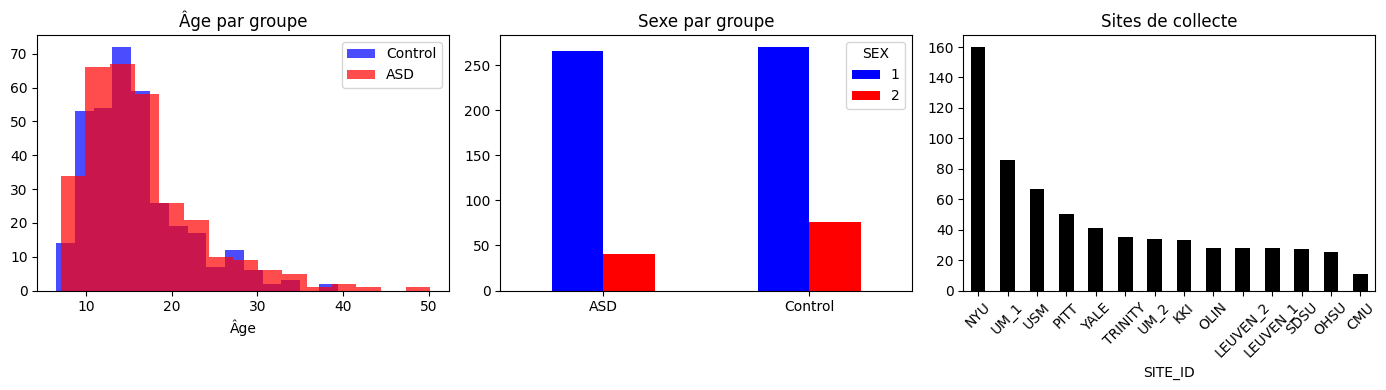

In [ ]:
# Exploration phénotypique
pheno = abide.phenotypic.copy()
pheno['label'] = (pheno['DX_GROUP'] == 1).astype(int)
pheno['groupe'] = pheno['label'].map({0: 'Control', 1: 'ASD'})

print("Distribution :")
print(pheno['label'].value_counts().rename({0: 'Control', 1: 'ASD'}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

#Graphe 1 : Âge par groupe
for grp, color in zip(['Control', 'ASD'], ['blue', 'red']):
    subset = pheno[pheno['groupe'] == grp]['AGE_AT_SCAN']
    axes[0].hist(subset, bins=15, alpha=0.7, color=color, label=grp)
axes[0].set_title('Âge par groupe')
axes[0].set_xlabel('Âge')
axes[0].legend()

#Graphe 2 : Sexe par groupe
pheno.groupby('groupe')['SEX'].value_counts().unstack().plot(
    kind='bar', ax=axes[1], color=['blue', 'red'])
axes[1].set_title('Sexe par groupe')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

#Graphe 3 : Sites de collecte
pheno['SITE_ID'].value_counts().plot(kind='bar', ax=axes[2], color='black')
axes[2].set_title('Sites de collecte')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Extraction des ROI et séries temporelles

L'atlas CC200 divise le cerveau en 200 régions d'intérêt. Pour chaque région, une série temporelle correspondant au signal BOLD moyen est extraite afin de décrire son évolution au fil du temps.

In [ ]:
def load_timeseries_from_abide(abide, atlas_name='cc200', signal_type='filt_global'):

    if isinstance(signal_type, bool):
        signal_type = 'filt_global' if signal_type else 'nofilt_global'

    key = f'rois_{atlas_name}'
    timeseries_list = []
    valid_indices   = []

    files = abide[key]

    for i, fpath in enumerate(tqdm(files, desc='Chargement séries temporelles')):
        try:
            ts = np.loadtxt(fpath)
            if ts.ndim == 2 and ts.shape[0] > 50:
                timeseries_list.append(ts)
                valid_indices.append(i)
        except Exception as e:
            print(f"  Erreur sujet {i}: {e}")

    return timeseries_list, valid_indices

print(list(abide.keys()))

['description', 'phenotypic', 'rois_cc200']


- Diagnostic de la structure des fichiers des séries temporelles

In [ ]:
# Diagnostic : voir ce que contient réellement abide['rois_cc200']
sample = abide['rois_cc200'][0]
print(type(sample))
print(sample)

<class 'numpy.ndarray'>
[[ -5.850851 -33.937427  -6.593561 ...  -3.667082 -39.567115 -35.527189]
 [-12.692127 -37.055576  -4.489373 ...  -2.019567 -37.707013 -37.962079]
 [-15.948725 -26.821254   4.347373 ...   1.148628 -17.806549 -29.741453]
 ...
 [ -7.720936   7.120426 -10.199512 ...  -9.741099 -43.670518 -16.795009]
 [-13.752676  -0.360954 -17.188173 ...  -5.759258 -25.512161 -29.55269 ]
 [-12.223003  -9.490451 -22.306749 ...  -0.044214  -8.794444 -30.125635]]


## Chargement, validation et préparation des séries temporelles rs-fMRI

In [ ]:
def load_timeseries_from_abide(abide, atlas_name='cc200'):
    key = f'rois_{atlas_name}'
    timeseries_list = []
    valid_indices   = []

    files = abide[key]

    for i, item in enumerate(tqdm(files, desc='Chargement séries temporelles')):
        try:
            #  Cas 1 : déjà un array numpy
            if isinstance(item, np.ndarray):
                ts = item

            #  Cas 2 : chemin de fichier
            elif isinstance(item, (str, bytes)):
                path = item.decode() if isinstance(item, bytes) else item
                ts = np.loadtxt(path)

            #  Cas 3 : objet nibabel NIfTI
            else:
                import nibabel as nib
                img = nib.load(str(item))
                ts  = img.get_fdata()

            if ts.ndim == 2 and ts.shape[0] > 50:
                timeseries_list.append(ts)
                valid_indices.append(i)
            else:
                print(f"  Sujet {i} ignoré : shape={ts.shape}")

        except Exception as e:
            print(f"  Erreur sujet {i}: {e}")

    return timeseries_list, valid_indices

#Chargement des signaux temporels des ROI à partir de l'atlas CC200
timeseries_list, valid_idx = load_timeseries_from_abide(abide, atlas_name=ATLAS_NAME)

labels = abide.phenotypic['DX_GROUP'].values[valid_idx]
labels = (labels == 1).astype(int)

if len(timeseries_list) == 0:
    print(" Aucun sujet chargé — lancez d'abord le diagnostic ci-dessus")
else:
    N_ROIS = timeseries_list[0].shape[1]
    print(f"\n✓ {len(timeseries_list)} sujets valides")
    print(f"  ROIs      : {N_ROIS}")
    print(f"  Durée moy : {np.mean([ts.shape[0] for ts in timeseries_list]):.0f} volumes")
    print(f"  ASD       : {labels.sum()} | Control : {(labels==0).sum()}")

Chargement séries temporelles: 100%|██████████| 653/653 [00:00<00:00, 520007.69it/s]


✓ 653 sujets valides
  ROIs      : 200
  Durée moy : 209 volumes
  ASD       : 307 | Control : 346


## 3. Matrices de connectivité fonctionnelle

On calcule la **corrélation de Pearson** entre toutes les paires de ROI.  
Ces matrices 200×200 sont utilisées comme features statiques (baseline) et pour visualisation.

In [ ]:
#  Calcul des matrices de connectivité
correlation_measure = ConnectivityMeasure(
    kind='correlation',
    vectorize=False,
    discard_diagonal=True
)

print("Calcul des matrices de connectivité...")
conn_matrices = correlation_measure.fit_transform(timeseries_list)
print(f"Shape matrices : {conn_matrices.shape}")

# Vectorisation
def vectorize_upper_tri(matrices):
    n = matrices.shape[1]
    idx = np.triu_indices(n, k=1)
    return matrices[:, idx[0], idx[1]]

conn_vectors = vectorize_upper_tri(conn_matrices)
print(f"Features vectorisées : {conn_vectors.shape}  ({conn_vectors.shape[1]} features)")

Calcul des matrices de connectivité...
Shape matrices : (653, 200, 200)
Features vectorisées : (653, 19900)  (19900 features)


- Visualisation comparative des matrices de connectivité fonctionnelle entre les groupes ASD et Control

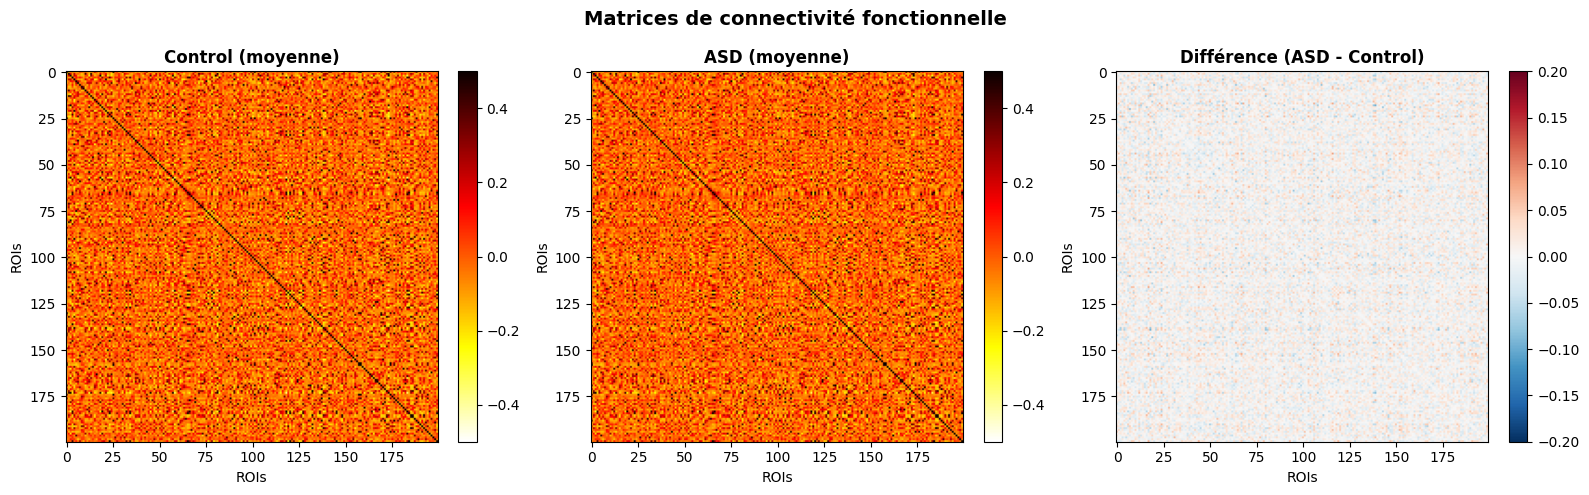

In [ ]:
# Visualisation : matrices moyennes ASD vs Control
asd_mean   = conn_matrices[labels == 1].mean(axis=0)
ctrl_mean  = conn_matrices[labels == 0].mean(axis=0)
diff_matrix = asd_mean - ctrl_mean

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vmax = 0.5

for ax, mat, title in zip(
    axes,
    [ctrl_mean, asd_mean, diff_matrix],
    ['Control (moyenne)', 'ASD (moyenne)', 'Différence (ASD - Control)']
):
    cmap = 'RdBu_r' if 'Diff' in title else 'hot_r'
    v = 0.2 if 'Diff' in title else vmax
    im = ax.imshow(mat, cmap=cmap, vmin=-v, vmax=v, aspect='auto')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('ROIs')
    ax.set_ylabel('ROIs')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Matrices de connectivité fonctionnelle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing pour Mamba

Mamba travaille sur des séquences temporelles. On prépare les données sous forme de tenseurs `(batch, time, n_rois)`.

In [ ]:
#  Paramètres séquences
SEQ_LEN = 150


def augment_timeseries(ts, noise_std=0.005, flip_prob=0.5, crop_ratio=0.9):
    """
    [ANTI-OVERFITTING] Augmentation offline appliquée au chargement.
    - Bruit gaussien très léger  : variabilité de mesure
    - Flip temporel              : invariance directionnelle
    - Crop aléatoire             : robustesse longueur
    """
    T, R = ts.shape
    ts = ts + np.random.randn(*ts.shape).astype(np.float32) * noise_std
    if np.random.rand() < flip_prob:
        ts = ts[::-1].copy()
    crop_len = int(T * crop_ratio)
    if crop_len < T:
        start = np.random.randint(0, T - crop_len)
        ts = ts[start:start + crop_len]
        if ts.shape[0] < SEQ_LEN:
            pad = np.zeros((SEQ_LEN - ts.shape[0], R), dtype=np.float32)
            ts = np.vstack([ts, pad])
        else:
            ts = ts[:SEQ_LEN]
    return ts.astype(np.float32)


def preprocess_timeseries(ts_list, seq_len=150, augment=False):
    """
    Z-score par ROI, tronque/padde à seq_len.
    augment=True uniquement pour le train set.
    """
    processed = []
    for ts in ts_list:
        ts = ts.astype(np.float32)
        ts = (ts - ts.mean(axis=0, keepdims=True)) / (ts.std(axis=0, keepdims=True) + 1e-8)
        T, R = ts.shape
        if T >= seq_len:
            start = (T - seq_len) // 2
            ts = ts[start:start + seq_len]
        else:
            pad = np.zeros((seq_len - T, R), dtype=np.float32)
            ts = np.vstack([ts, pad])
        if augment:
            ts = augment_timeseries(ts)
        processed.append(ts)
    return np.stack(processed, axis=0).astype(np.float32)


X_seq = preprocess_timeseries(timeseries_list, seq_len=SEQ_LEN, augment=False)
y     = labels.astype(np.int64)

print(f"X_seq shape : {X_seq.shape}")
print(f"y shape     : {y.shape}  (ASD={y.sum()}, Control={(y==0).sum()})")


X_seq shape : (653, 150, 200)
y shape     : (653,)  (ASD=307, Control=346)


- Cette classe ABIDEDataset crée un dataset personnalisé pour PyTorch afin d’entraîner ton modèle sur les données fMRI du dataset ABIDE.

In [ ]:
class ABIDEDataset(Dataset):
    def __init__(self, X, y, conn=None, augment=False):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.conn    = torch.tensor(conn, dtype=torch.float32) if conn is not None else None
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].numpy()
        if self.augment:
            x = augment_timeseries(x)
        x = torch.tensor(x, dtype=torch.float32)
        if self.conn is not None:
            return x, self.conn[idx], self.y[idx]
        return x, self.y[idx]


## 5. Architecture Mamba (implémentation PyTorch pure)


- Cette classe implémente le cœur d’un modèle Mamba State Space Models basé sur les Selective State Space Models (SSM) pour la modélisation des séries temporelles fMRI.

In [ ]:
class SelectiveSSM(nn.Module):
    """
    Selective State Space Model (cœur de Mamba)

    Paramètres :
        d_model : dimension du modèle (D)
        d_state : dimension de l'état caché (N)
        d_rank  : rang pour la projection de Δ (typiquement D//16)
    """
    def __init__(self, d_model: int, d_state: int = 16, d_rank: int = None):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_rank  = d_rank or max(1, d_model // 16)


        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        A = A.repeat(d_model, 1)
        self.log_A_neg = nn.Parameter(torch.log(A))


        self.x_proj = nn.Linear(d_model, self.d_rank + d_state * 2, bias=False)

        self.dt_proj = nn.Linear(self.d_rank, d_model, bias=True)
        nn.init.uniform_(self.dt_proj.bias, -4, -1)


        self.D = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, T, D)
        Retourne : (B, T, D)
        """
        B, T, D = x.shape
        N = self.d_state

        #  Projections sélectives
        xz = self.x_proj(x)
        dt_raw, B_mat, C_mat = xz.split([self.d_rank, N, N], dim=-1)


        dt = F.softplus(self.dt_proj(dt_raw))


        A = -torch.exp(self.log_A_neg)

        #  Scan séquentiel

        h = torch.zeros(B, D, N, device=x.device, dtype=x.dtype)  # état caché
        ys = []

        for t in range(T):
            xt  = x[:, t, :]
            dtt = dt[:, t, :]
            Bt  = B_mat[:, t, :]
            Ct  = C_mat[:, t, :]

            # Discrétisation ZOH

            dA = torch.exp(dtt.unsqueeze(-1) * A.unsqueeze(0))

            dB = dtt.unsqueeze(-1) * Bt.unsqueeze(1)

            # Mise à jour état caché
            h = dA * h + dB * xt.unsqueeze(-1)

            # Sortie : yₜ = C·h + D·x
            y = (h * Ct.unsqueeze(1)).sum(dim=-1)
            y = y + self.D * xt
            ys.append(y)

        return torch.stack(ys, dim=1)

print("SelectiveSSM défini ")

SelectiveSSM défini 


- Implémentation du bloc Mamba avec mécanismes de régularisation anti-overfitting adaptés aux données fMRI du dataset ABIDE.

In [ ]:
class DropPath(nn.Module):
    """[ANTI-OVERFITTING] Stochastic Depth : bypass aléatoire d'un bloc entier."""
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep  = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask  = torch.bernoulli(torch.full(shape, keep, device=x.device))
        return x * mask / keep


class MambaBlock(nn.Module):
    """
    Bloc Mamba avec :
    - RMSNorm, double projection, conv causale 1D, SSM, gate SiLU, résidu
    - [ANTI-OVERFITTING] Dropout interne (post-conv, post-SSM)
    - [ANTI-OVERFITTING] DropPath sur le résidu (stochastic depth)
    """
    def __init__(self, d_model: int, d_state: int = 16, expand: int = 2,
                 d_conv: int = 4, dt_rank: int = None,
                 dropout: float = 0.1, drop_path: float = 0.1):
        super().__init__()
        self.d_inner  = d_model * expand
        self.norm     = nn.RMSNorm(d_model)
        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(
            self.d_inner, self.d_inner, kernel_size=d_conv,
            groups=self.d_inner, padding=d_conv - 1, bias=True
        )
        self.ssm      = SelectiveSSM(self.d_inner, d_state=d_state, d_rank=dt_rank)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.dropout   = nn.Dropout(dropout)
        self.drop_path = DropPath(drop_path)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm(x)
        xz      = self.in_proj(x)
        x_in, z = xz.chunk(2, dim=-1)
        x_conv  = self.conv1d(x_in.transpose(1, 2))[:, :, :x_in.shape[1]]
        x_conv  = F.silu(x_conv.transpose(1, 2))
        x_conv  = self.dropout(x_conv)
        y = self.ssm(x_conv)
        y = y * F.silu(z)
        y = self.dropout(y)
        return residual + self.drop_path(self.out_proj(y))


print("MambaBlock (DropPath + Dropout interne) défini OK")


MambaBlock (DropPath + Dropout interne) défini OK


- Architecture du modèle MambaFMRI pour la classification ASD/Control

In [ ]:
class MambaFMRI(nn.Module):
    """
    Mamba pour classification ASD/Control sur fMRI

    [ANTI-OVERFITTING] :
      - n_layers réduit (1-2) pour petit dataset
      - d_model réduit (32) → moins de paramètres
      - DropPath schedule linéaire par couche
      - Dropout dans chaque bloc et dans le classifieur
    """
    def __init__(self, n_rois=200, d_model=32, d_state=16, n_layers=2,
                 expand=2, dropout=0.5, drop_path_rate=0.2,
                 n_classes=2, conn_dim=0):
        super().__init__()
        self.use_conn = conn_dim > 0

        self.input_proj = nn.Sequential(
            nn.Linear(n_rois, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        dp_rates = [drop_path_rate * i / max(n_layers - 1, 1) for i in range(n_layers)]
        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model=d_model, d_state=d_state, expand=expand,
                       dropout=dropout * 0.5, drop_path=dp_rates[i])
            for i in range(n_layers)
        ])

        self.final_norm = nn.RMSNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

        if self.use_conn:
            # ANTI-OVERFITTING conn_encoder simplifié
            self.conn_encoder = nn.Sequential(
                nn.Linear(conn_dim, d_model * 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model * 2, d_model),
                nn.LayerNorm(d_model),
            )

        head_in = d_model * 2 + (d_model if self.use_conn else 0)
        self.classifier = nn.Sequential(
            nn.Linear(head_in, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x, conn=None):
        h = self.input_proj(x)
        for layer in self.mamba_layers:
            h = layer(h)
        h = self.final_norm(h)
        h = self.dropout(h)
        feat = torch.cat([h.mean(dim=1), h.max(dim=1).values], dim=-1)
        if self.use_conn and conn is not None:
            feat = torch.cat([feat, self.conn_encoder(conn)], dim=-1)
        return self.classifier(feat)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model  = MambaFMRI(n_rois=N_ROIS, d_model=32, d_state=16, n_layers=2)
x_test = torch.randn(2, SEQ_LEN, N_ROIS)
out    = model(x_test)
print(f"Modèle MambaFMRI OK  |  Paramètres : {model.count_params():,}  |  Output : {out.shape}")


Modèle MambaFMRI OK  |  Paramètres : 29,090  |  Output : torch.Size([2, 2])


## 6. Entraînement avec validation croisée


- Implémentation des fonctions d'entraînement et d'évaluation du modèle

Cette cellule implémente la pipeline d'entraînement et d'évaluation du modèle, en intégrant plusieurs techniques de régularisation (Mixup, Label Smoothing, Gradient Clipping) ainsi que le calcul des métriques de validation.

In [ ]:
def mixup_batch(X, y, alpha=0.3):
    """[ANTI-OVERFITTING] Mixup : interpole des paires d'exemples et leurs labels."""
    lam = float(np.random.beta(alpha, alpha))
    lam = max(lam, 1 - lam)
    idx     = torch.randperm(X.size(0), device=X.device)
    X_mixed = lam * X + (1 - lam) * X[idx]
    return X_mixed, y, y[idx], lam


def train_epoch(model, loader, optimizer, criterion_smooth, device,
                use_mixup=True, mixup_alpha=0.3):
    """
    criterion_smooth : CrossEntropyLoss avec label_smoothing (train uniquement).
    Le Mixup est appliqué sur les batches pour créer des exemples virtuels.
    """
    model.train()
    total_loss, correct, total = 0., 0, 0
    for batch in loader:
        if len(batch) == 3:
            X, conn, y = [b.to(device) for b in batch]
        else:
            X, y = [b.to(device) for b in batch]
            conn = None

        if use_mixup:
            X, y_a, y_b, lam = mixup_batch(X, y, alpha=mixup_alpha)
            logits = model(X, conn) if conn is not None else model(X)
            loss   = lam * criterion_smooth(logits, y_a) + (1 - lam) * criterion_smooth(logits, y_b)
        else:
            logits = model(X, conn) if conn is not None else model(X)
            loss   = criterion_smooth(logits, y)
            y_a    = y

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(-1) == y_a).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion_hard, device):
    """
    criterion_hard : CrossEntropyLoss SANS label_smoothing.
    Donne une val_loss comparable et non biaisée pour l'early stopping.
    """
    model.eval()
    total_loss, correct, total = 0., 0, 0
    all_probs, all_labels = [], []
    for batch in loader:
        if len(batch) == 3:
            X, conn, y = [b.to(device) for b in batch]
            logits = model(X, conn)
        else:
            X, y = [b.to(device) for b in batch]
            logits = model(X)

        loss  = criterion_hard(logits, y)
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(-1) == y).sum().item()
        total      += len(y)
        all_probs.extend(probs)
        all_labels.extend(y.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.
    return total_loss / total, correct / total, auc


print("Fonctions d'entraînement (Mixup séparé de l'évaluation) définies OK")


Fonctions d'entraînement (Mixup séparé de l'évaluation) définies OK


- Configuration des hyperparamètres et entraînement du modèle MambaFMRI par validation croisée

In [ ]:
# Hyperparamètres (anti-overfitting sévère)
CONFIG = dict(
    # Architecture réduite
    d_model        = 32,
    d_state        = 16,
    n_layers       = 2,
    expand         = 2,
    # Régularisation forte
    dropout        = 0.5,
    drop_path_rate = 0.2,
    weight_decay   = 5e-2,
    label_smoothing= 0.15,
    mixup_alpha    = 0.3,
    # Optimisation
    lr             = 5e-5,
    batch_size     = 32,
    n_epochs       = 100,
    patience       = 20,
    n_folds        = 5,
    use_conn       = True,
)


skf     = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=42)
results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_seq, y)):
    print(f"\n{'='*55}")
    print(f"  Fold {fold+1}/{CONFIG['n_folds']}")
    print(f"{'='*55}")

    X_tr, X_val = X_seq[train_idx], X_seq[val_idx]
    y_tr, y_val = y[train_idx],     y[val_idx]
    c_tr, c_val = conn_vectors[train_idx], conn_vectors[val_idx]

    scaler = StandardScaler()
    c_tr   = scaler.fit_transform(c_tr).astype(np.float32)
    c_val  = scaler.transform(c_val).astype(np.float32)

    conn_dim = c_tr.shape[1] if CONFIG['use_conn'] else 0

    # augment=True train / False val
    train_ds = ABIDEDataset(X_tr, y_tr, c_tr if CONFIG['use_conn'] else None, augment=True)
    val_ds   = ABIDEDataset(X_val, y_val, c_val if CONFIG['use_conn'] else None, augment=False)
    train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False)

    model = MambaFMRI(
        n_rois         = N_ROIS,
        d_model        = CONFIG['d_model'],
        d_state        = CONFIG['d_state'],
        n_layers       = CONFIG['n_layers'],
        expand         = CONFIG['expand'],
        dropout        = CONFIG['dropout'],
        drop_path_rate = CONFIG['drop_path_rate'],
        conn_dim       = conn_dim,
    ).to(DEVICE)

    class_counts  = np.bincount(y_tr)
    class_weights = torch.tensor(1. / class_counts, dtype=torch.float32).to(DEVICE)

    # Deux critères : smooth pour train, hard pour val
    criterion_smooth = nn.CrossEntropyLoss(weight=class_weights,
                                           label_smoothing=CONFIG['label_smoothing'])
    criterion_hard   = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay']
    )

    # ReduceLROnPlateau sur val_loss brute
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7
    )

    best_val_loss = float('inf')
    best_val_auc  = 0.
    best_state    = None
    no_improve    = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

    for epoch in range(CONFIG['n_epochs']):
        tr_loss, tr_acc      = train_epoch(model, train_dl, optimizer, criterion_smooth,
                                            DEVICE, use_mixup=True,
                                            mixup_alpha=CONFIG['mixup_alpha'])
        val_loss, val_acc, val_auc = eval_epoch(model, val_dl, criterion_hard, DEVICE)
        scheduler.step(val_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        # Early Stopping sur val_loss brute
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_auc  = val_auc
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else :
            no_improve += 1

        if (epoch + 1) % 5 == 0:
            gap = val_loss - tr_loss
            print(f"  Epoch {epoch+1:3d} | "
                  f"Train {tr_loss:.3f} ({tr_acc:.2f}) | "
                  f"Val {val_loss:.3f} ({val_acc:.2f}) AUC {val_auc:.3f} | "
                  f"Gap {gap:+.3f} | patience {no_improve}/{CONFIG['patience']}")

        if no_improve >= CONFIG['patience']:
            print(f"  Early stopping epoch {epoch+1}")
            break

    results.append({'fold': fold+1, 'best_auc': best_val_auc,
                    'best_val_loss': best_val_loss,
                    'history': history, 'best_state': best_state})
    print(f"  -> Best val_loss {best_val_loss:.4f}  |  Best AUC {best_val_auc:.3f}")

print("\n" + "="*55)
aucs = [r['best_auc'] for r in results]
print(f"AUC moyen : {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")



  Fold 1/5
  Epoch   5 | Train 0.737 (0.60) | Val 0.619 (0.63) AUC 0.744 | Gap -0.118 | patience 0/20
  Epoch  10 | Train 0.548 (0.81) | Val 0.579 (0.69) AUC 0.799 | Gap +0.031 | patience 0/20
  Epoch  15 | Train 0.497 (0.92) | Val 0.553 (0.73) AUC 0.814 | Gap +0.056 | patience 1/20
  Epoch  20 | Train 0.430 (0.98) | Val 0.552 (0.73) AUC 0.805 | Gap +0.122 | patience 2/20
  Epoch  25 | Train 0.385 (0.99) | Val 0.565 (0.72) AUC 0.792 | Gap +0.181 | patience 7/20
  Epoch  30 | Train 0.436 (0.99) | Val 0.567 (0.71) AUC 0.797 | Gap +0.132 | patience 12/20
  Epoch  35 | Train 0.406 (1.00) | Val 0.570 (0.71) AUC 0.801 | Gap +0.164 | patience 17/20
  Early stopping epoch 38
  -> Best val_loss 0.5406  |  Best AUC 0.820

  Fold 2/5
  Epoch   5 | Train 0.669 (0.62) | Val 0.639 (0.79) AUC 0.820 | Gap -0.030 | patience 0/20
  Epoch  10 | Train 0.599 (0.76) | Val 0.590 (0.79) AUC 0.838 | Gap -0.009 | patience 0/20
  Epoch  15 | Train 0.527 (0.91) | Val 0.540 (0.82) AUC 0.846 | Gap +0.013 | patienc

## 7. Visualisation des résultats

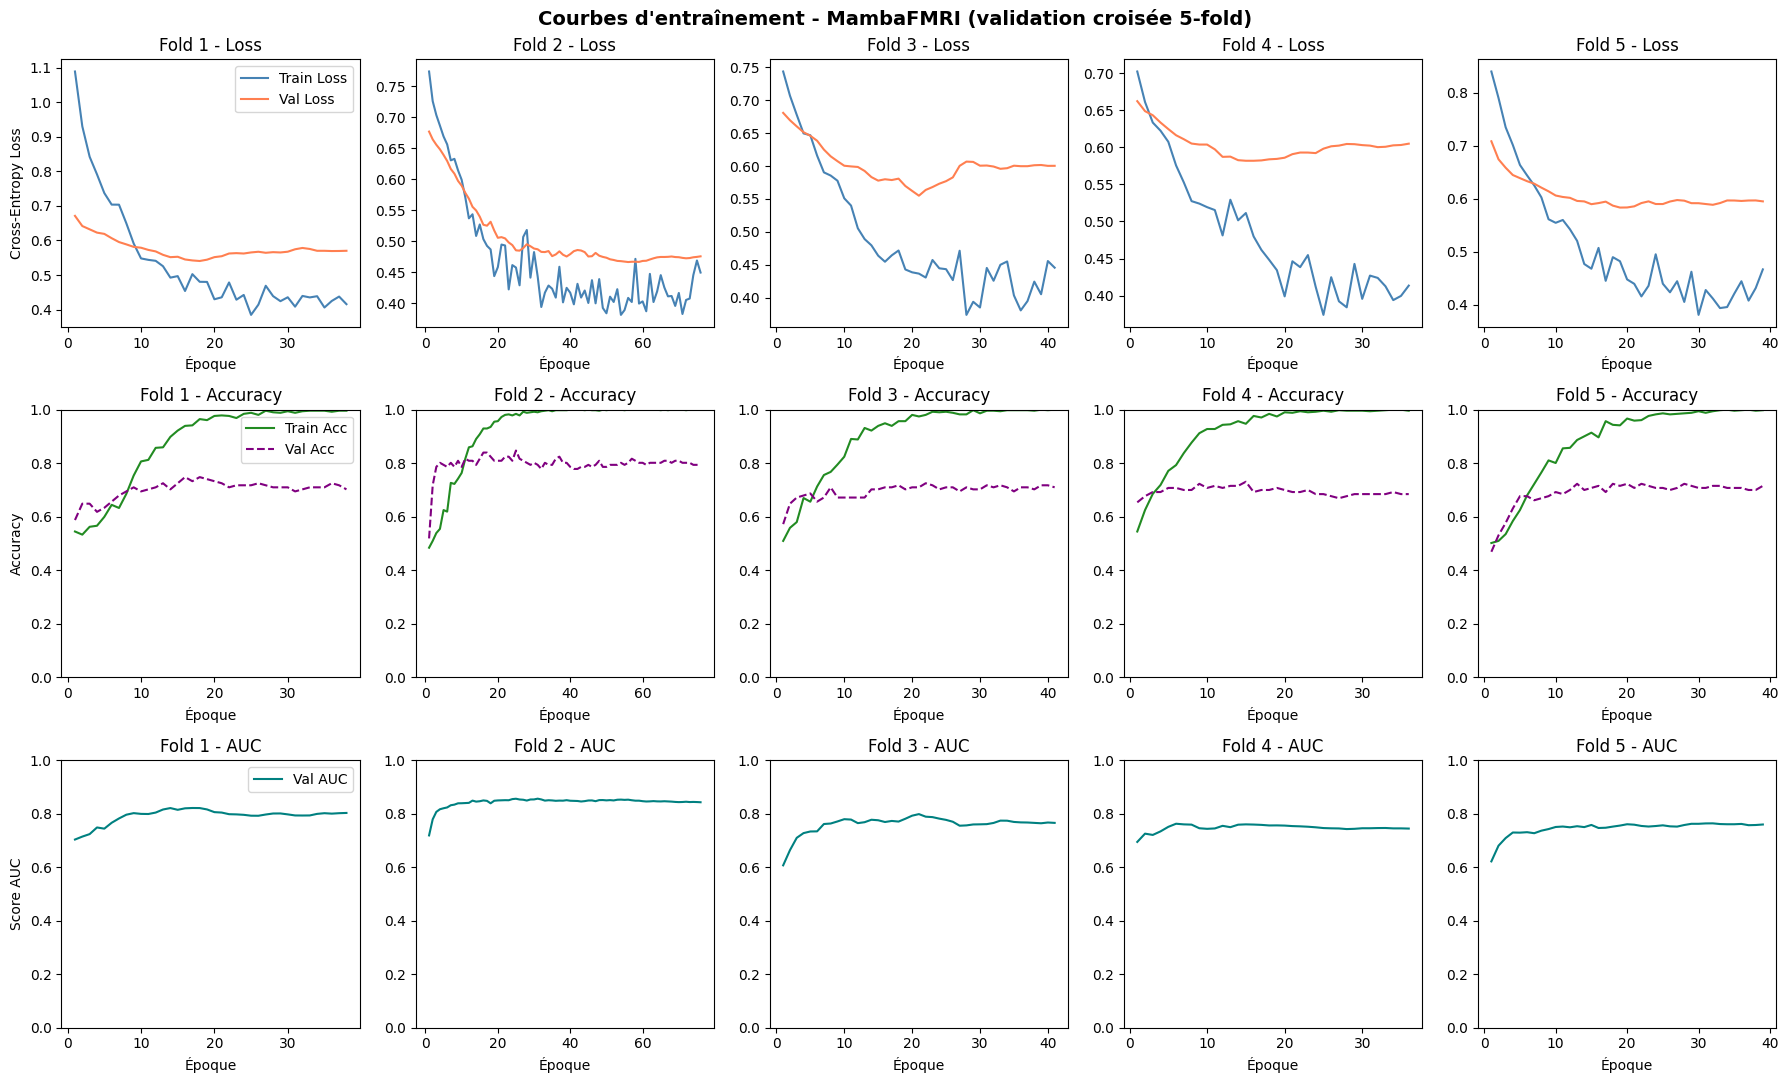


---------
Résumé par fold :
  Fold 1 : AUC = 0.820
  Fold 2 : AUC = 0.852
  Fold 3 : AUC = 0.798
  Fold 4 : AUC = 0.759
  Fold 5 : AUC = 0.755

  Moyenne : 0.797 ± 0.037


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration de la figure : 3 lignes (Loss, Accuracy, AUC)
fig, axes = plt.subplots(3, CONFIG['n_folds'], figsize=(18, 11))

for fold_idx, res in enumerate(results):
    h = res['history']
    epochs = range(1, len(h['train_loss']) + 1)

    # --- 1. LIGNE DU HAUT : LOSS ---
    ax = axes[0, fold_idx]
    ax.plot(epochs, h['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(epochs, h['val_loss'],   label='Val Loss',   color='coral')
    ax.set_title(f"Fold {fold_idx+1} - Loss")
    ax.set_xlabel('Époque')
    if fold_idx == 0:
        ax.legend()
        ax.set_ylabel('Cross-Entropy Loss')

    # --- 2. LIGNE DU MILIEU : ACCURACY (Train vs Val) ---
    ax = axes[1, fold_idx]
    # On vérifie si train_acc est présent, sinon on gère l'exception
    if 'train_acc' in h:
        ax.plot(epochs, h['train_acc'], label='Train Acc', color='forestgreen')
    ax.plot(epochs, h['val_acc'],   label='Val Acc',   color='purple', linestyle='--')
    ax.set_title(f"Fold {fold_idx+1} - Accuracy")
    ax.set_xlabel('Époque')
    ax.set_ylim(0, 1)
    if fold_idx == 0:
        ax.legend()
        ax.set_ylabel('Accuracy')

    # --- 3. LIGNE DU BAS : AUC ---
    ax = axes[2, fold_idx]
    ax.plot(epochs, h['val_auc'],  color='teal',   label='Val AUC')
    ax.set_title(f"Fold {fold_idx+1} - AUC")
    ax.set_xlabel('Époque')
    ax.set_ylim(0, 1)
    if fold_idx == 0:
        ax.legend()
        ax.set_ylabel('Score AUC')

# Titre principal et ajustements
plt.suptitle('Courbes d\'entraînement - MambaFMRI (validation croisée 5-fold)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- RÉSUMÉ DES PERFORMANCES ---
print("\n---------")
print("Résumé par fold :")

# Extraction des AUCs pour le calcul de la moyenne (au cas où la variable 'aucs' n'était pas définie plus haut)
aucs = [res['best_auc'] for res in results]

for res in results:
    print(f"  Fold {res['fold']} : AUC = {res['best_auc']:.3f}")
print(f"\n  Moyenne : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

In [ ]:
# Charger le meilleur modèle
best_fold  = results[np.argmax(aucs)]
best_model = MambaFMRI(
    n_rois=N_ROIS, d_model=CONFIG['d_model'], d_state=CONFIG['d_state'],
    n_layers=CONFIG['n_layers'], expand=CONFIG['expand'],
    dropout=0., conn_dim=conn_vectors.shape[1] if CONFIG['use_conn'] else 0
).to(DEVICE)
best_model.load_state_dict({k: v.to(DEVICE) for k, v in best_fold['best_state'].items()})
best_model.eval()

MambaFMRI(
  (input_proj): Sequential(
    (0): Linear(in_features=200, out_features=32, bias=True)
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
  )
  (mamba_layers): ModuleList(
    (0-1): 2 x MambaBlock(
      (norm): RMSNorm((32,), eps=None, elementwise_affine=True)
      (in_proj): Linear(in_features=32, out_features=128, bias=False)
      (conv1d): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(3,), groups=64)
      (ssm): SelectiveSSM(
        (x_proj): Linear(in_features=64, out_features=36, bias=False)
        (dt_proj): Linear(in_features=4, out_features=64, bias=True)
      )
      (out_proj): Linear(in_features=64, out_features=32, bias=False)
      (dropout): Dropout(p=0.0, inplace=False)
      (drop_path): DropPath()
    )
  )
  (final_norm): RMSNorm((32,), eps=None, elementwise_affine=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (conn_encoder): Sequential(
    (0): Linear(in_features=19900, out_features=64, 

## 9. Sauvegarder le modèle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
save_path = '/content/drive/MyDrive/Master AI/ASD/mamba_fmri_best-4.pt'

torch.save({
    'model_state': best_fold['best_state'],
    'config':      CONFIG,
    'n_rois':      N_ROIS,
    'seq_len':     SEQ_LEN,
    'conn_dim':    conn_vectors.shape[1],
    'results':     [{'fold': r['fold'], 'best_auc': r['best_auc']} for r in results],
}, save_path)

print(f"Modèle sauvegardé : {save_path}")

# Chargement
def load_mamba_fmri(path, device='cpu'):
    ck = torch.load(path, map_location=device)
    model = MambaFMRI(
        n_rois=ck['n_rois'], conn_dim=ck['conn_dim'],
        **{k: ck['config'][k] for k in ['d_model','d_state','n_layers','expand','dropout']}
    )
    model.load_state_dict(ck['model_state'])
    return model.to(device)

print("Fonction de chargement définie ")

Modèle sauvegardé : /content/drive/MyDrive/Master AI/ASD/mamba_fmri_best-4.pt
Fonction de chargement définie 


## 8. Visualisation de la matrice de confusion

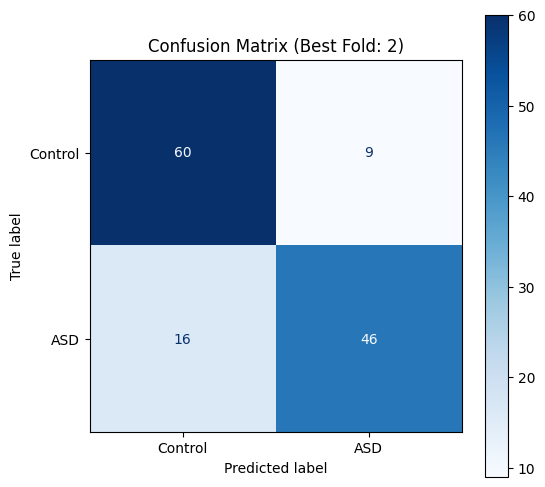

Classification Report for the Best Fold:
              precision    recall  f1-score   support

     Control       0.79      0.87      0.83        69
         ASD       0.84      0.74      0.79        62

    accuracy                           0.81       131
   macro avg       0.81      0.81      0.81       131
weighted avg       0.81      0.81      0.81       131



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the indices for the best fold's validation set
best_fold_idx = np.argmax(aucs)
_, val_idx_best_fold = list(skf.split(X_seq, y))[best_fold_idx]

# Prepare the validation data for the best fold
X_val_best_fold = X_seq[val_idx_best_fold]
y_val_best_fold = y[val_idx_best_fold]
c_val_best_fold = conn_vectors[val_idx_best_fold]


scaler_for_viz = StandardScaler()

scaler_for_viz.fit(conn_vectors)
c_val_best_fold_scaled = scaler_for_viz.transform(c_val_best_fold).astype(np.float32)

val_ds_best_fold = ABIDEDataset(
    X_val_best_fold, y_val_best_fold,
    c_val_best_fold_scaled if CONFIG['use_conn'] else None,
    augment=False
)
val_dl_best_fold = DataLoader(val_ds_best_fold, batch_size=CONFIG['batch_size'], shuffle=False)

# Make predictions with the best model
all_preds    = []
all_labels   = []

best_model.eval()
with torch.no_grad():
    for batch in val_dl_best_fold:
        if len(batch) == 3:
            X, conn, y_true = [b.to(DEVICE) for b in batch]
            logits = best_model(X, conn)
        else:
            X, y_true = [b.to(DEVICE) for b in batch]
            logits = best_model(X)

        predictions = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(predictions)
        all_labels.extend(y_true.cpu().numpy())

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])


fig, ax = plt.subplots(figsize=(6, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Control', 'ASD'])
display_cm.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title(f'Confusion Matrix (Best Fold: {best_fold_idx+1})')
plt.grid(False)
plt.show()

print("Classification Report for the Best Fold:")
print(classification_report(all_labels, all_preds, target_names=['Control', 'ASD']))

## 11. Comparaison Mamba vs LSTM vs Transformer

On entraîne trois modèles sur **exactement les mêmes conditions** :
- Mêmes données (X_seq, conn_vectors, y)
- Même split StratifiedKFold (random_state=42)
- Même preprocessing et augmentation (Mixup, bruit, flip, crop)
- Même CONFIG (lr, weight_decay, dropout, batch_size, patience…)
- Même boucle d'entraînement (Label Smoothing, Early Stopping)

Seule différence : l'architecture interne.


### 11.1 Architecture du modèle LSTMFMRI pour la classification ASD/Control

In [ ]:
class LSTMFMRI(nn.Module):
    """
    LSTM bidirectionnel pour classification ASD/Control sur fMRI.
    Conçu pour être comparable à MambaFMRI :
    - Même input  : (B, T, n_rois)
    - Même output : logits (B, 2)
    - Même pooling temporel (mean + max)
    - Même classifieur MLP
    - Même régularisation (Dropout)
    """
    def __init__(self, n_rois=200, d_model=32, n_layers=2,
                 dropout=0.5, n_classes=2, conn_dim=0):
        super().__init__()
        self.use_conn = conn_dim > 0

        # Projection initiale identique à Mamba
        self.input_proj = nn.Sequential(
            nn.Linear(n_rois, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        # LSTM bidirectionnel
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model // 2,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        if self.use_conn:
            self.conn_encoder = nn.Sequential(
                nn.Linear(conn_dim, d_model * 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model * 2, d_model),
                nn.LayerNorm(d_model),
            )

        head_in = d_model * 2 + (d_model if self.use_conn else 0)
        self.classifier = nn.Sequential(
            nn.Linear(head_in, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x, conn=None):
        h = self.input_proj(x)
        h, _ = self.lstm(h)
        h = self.norm(h)
        h = self.dropout(h)

        # Même pooling que Mamba (mean + max)
        feat = torch.cat([h.mean(dim=1), h.max(dim=1).values], dim=-1)

        if self.use_conn and conn is not None:
            feat = torch.cat([feat, self.conn_encoder(conn)], dim=-1)

        return self.classifier(feat)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Vérification
lstm_test = LSTMFMRI(n_rois=N_ROIS, d_model=32, n_layers=2)
out_test  = lstm_test(torch.randn(2, SEQ_LEN, N_ROIS))
print(f"LSTMFMRI OK  |  Paramètres : {lstm_test.count_params():,}")
print(f"MambaFMRI    |  Paramètres : {MambaFMRI(n_rois=N_ROIS, d_model=32, n_layers=2).count_params():,}")
print(f"Output shape : {out_test.shape}")


LSTMFMRI OK  |  Paramètres : 21,506
MambaFMRI    |  Paramètres : 29,090
Output shape : torch.Size([2, 2])


### 11.2 Entraînement LSTM (mêmes conditions que Mamba)

In [ ]:
#  Même CONFIG, même split, même boucle
results_lstm = []

for fold, (train_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=42
    ).split(X_seq, y)
):
    print(f"\n{'='*50}")
    print(f"  LSTM — Fold {fold+1}/{CONFIG['n_folds']}")
    print(f"{'='*50}")

    X_tr, X_val = X_seq[train_idx], X_seq[val_idx]
    y_tr, y_val = y[train_idx],     y[val_idx]
    c_tr, c_val = conn_vectors[train_idx], conn_vectors[val_idx]

    scaler = StandardScaler()
    c_tr   = scaler.fit_transform(c_tr).astype(np.float32)
    c_val  = scaler.transform(c_val).astype(np.float32)

    conn_dim = c_tr.shape[1] if CONFIG['use_conn'] else 0

    # Même Dataset avec augmentation
    train_ds = ABIDEDataset(X_tr, y_tr, c_tr if CONFIG['use_conn'] else None, augment=True)
    val_ds   = ABIDEDataset(X_val, y_val, c_val if CONFIG['use_conn'] else None, augment=False)
    train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False)

    model_lstm = LSTMFMRI(
        n_rois   = N_ROIS,
        d_model  = CONFIG['d_model'],
        n_layers = CONFIG['n_layers'],
        dropout  = CONFIG['dropout'],
        conn_dim = conn_dim,
    ).to(DEVICE)

    class_counts  = np.bincount(y_tr)
    class_weights = torch.tensor(1. / class_counts, dtype=torch.float32).to(DEVICE)

    # Même critères que Mamba
    criterion_smooth = nn.CrossEntropyLoss(weight=class_weights,
                                           label_smoothing=CONFIG['label_smoothing'])
    criterion_hard   = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model_lstm.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
       optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7
    )

    best_val_loss = float('inf')
    best_val_auc  = 0.
    best_state    = None
    no_improve    = 0
    history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

    for epoch in range(CONFIG['n_epochs']):
        tr_loss, tr_acc           = train_epoch(model_lstm, train_dl, optimizer,
                                                 criterion_smooth, DEVICE,
                                                 use_mixup=True,
                                                 mixup_alpha=CONFIG['mixup_alpha'])
        val_loss, val_acc, val_auc = eval_epoch(model_lstm, val_dl, criterion_hard, DEVICE)
        scheduler.step(val_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_auc  = val_auc
            best_state    = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Train {tr_loss:.3f} ({tr_acc:.2f}) | "
                  f"Val {val_loss:.3f} ({val_acc:.2f}) AUC {val_auc:.3f} | "
                  f"patience {no_improve}/{CONFIG['patience']}")

        if no_improve >= CONFIG['patience']:
            print(f"  Early stopping epoch {epoch+1}")
            break

    results_lstm.append({'fold': fold+1, 'best_auc': best_val_auc,
                         'best_val_loss': best_val_loss,
                         'history': history, 'best_state': best_state})
    print(f"  -> Best val_loss {best_val_loss:.4f}  |  Best AUC {best_val_auc:.3f}")

aucs_lstm = [r['best_auc'] for r in results_lstm]
print(f"\nLSTM  — AUC : {np.mean(aucs_lstm):.3f} +/- {np.std(aucs_lstm):.3f}")
aucs_mamba = [r['best_auc'] for r in results]
print(f"Mamba — AUC : {np.mean(aucs_mamba):.3f} +/- {np.std(aucs_mamba):.3f}")



  LSTM — Fold 1/5
  Epoch  10 | Train 0.497 (0.93) | Val 0.587 (0.69) AUC 0.767 | patience 0/20
  Epoch  20 | Train 0.409 (0.99) | Val 0.594 (0.69) AUC 0.766 | patience 7/20
  Epoch  30 | Train 0.408 (1.00) | Val 0.586 (0.71) AUC 0.774 | patience 6/20
  Epoch  40 | Train 0.398 (1.00) | Val 0.581 (0.72) AUC 0.782 | patience 16/20
  Early stopping epoch 44
  -> Best val_loss 0.5707  |  Best AUC 0.786

  LSTM — Fold 2/5
  Epoch  10 | Train 0.546 (0.90) | Val 0.559 (0.78) AUC 0.850 | patience 0/20
  Epoch  20 | Train 0.441 (0.99) | Val 0.501 (0.76) AUC 0.846 | patience 0/20
  Epoch  30 | Train 0.401 (1.00) | Val 0.497 (0.76) AUC 0.839 | patience 2/20
  Epoch  40 | Train 0.369 (1.00) | Val 0.459 (0.83) AUC 0.869 | patience 0/20
  Epoch  50 | Train 0.464 (1.00) | Val 0.477 (0.81) AUC 0.856 | patience 10/20
  Epoch  60 | Train 0.418 (1.00) | Val 0.475 (0.81) AUC 0.860 | patience 20/20
  Early stopping epoch 60
  -> Best val_loss 0.4590  |  Best AUC 0.869

  LSTM — Fold 3/5
  Epoch  10 | Trai

### 11.3 Tableau comparatif Mamba vs LSTM

In [ ]:
#  Métriques par fold
print(f"{'Fold':<6} {'Mamba AUC':>10} {'LSTM AUC':>10} {'Δ (Mamba-LSTM)':>15}")
print("-" * 45)
for i in range(CONFIG['n_folds']):
    m_auc = results[i]['best_auc']
    l_auc = results_lstm[i]['best_auc']
    print(f"  {i+1:<4} {m_auc:>10.4f} {l_auc:>10.4f} {m_auc - l_auc:>+15.4f}")

print("-" * 45)
m_mean, m_std = np.mean(aucs_mamba), np.std(aucs_mamba)
l_mean, l_std = np.mean(aucs_lstm),  np.std(aucs_lstm)
print(f"  {'Moy':<4} {m_mean:>10.4f} {l_mean:>10.4f} {m_mean - l_mean:>+15.4f}")
print(f"  {'Std':<4} {m_std:>10.4f} {l_std:>10.4f}")
print()

# Paramètres
n_params_mamba = MambaFMRI(n_rois=N_ROIS, d_model=CONFIG['d_model'],
                            n_layers=CONFIG['n_layers']).count_params()
n_params_lstm  = LSTMFMRI(n_rois=N_ROIS,  d_model=CONFIG['d_model'],
                           n_layers=CONFIG['n_layers']).count_params()
print(f"Paramètres Mamba : {n_params_mamba:,}")
print(f"Paramètres LSTM  : {n_params_lstm:,}")


Fold    Mamba AUC   LSTM AUC  Δ (Mamba-LSTM)
---------------------------------------------
  1        0.8205     0.7856         +0.0348
  2        0.8518     0.8691         -0.0173
  3        0.7979     0.7534         +0.0445
  4        0.7589     0.7403         +0.0185
  5        0.7550     0.7463         +0.0088
---------------------------------------------
  Moy      0.7968     0.7789         +0.0179
  Std      0.0368     0.0477

Paramètres Mamba : 29,090
Paramètres LSTM  : 21,506


### 11.4 Visualisation de la comparaison

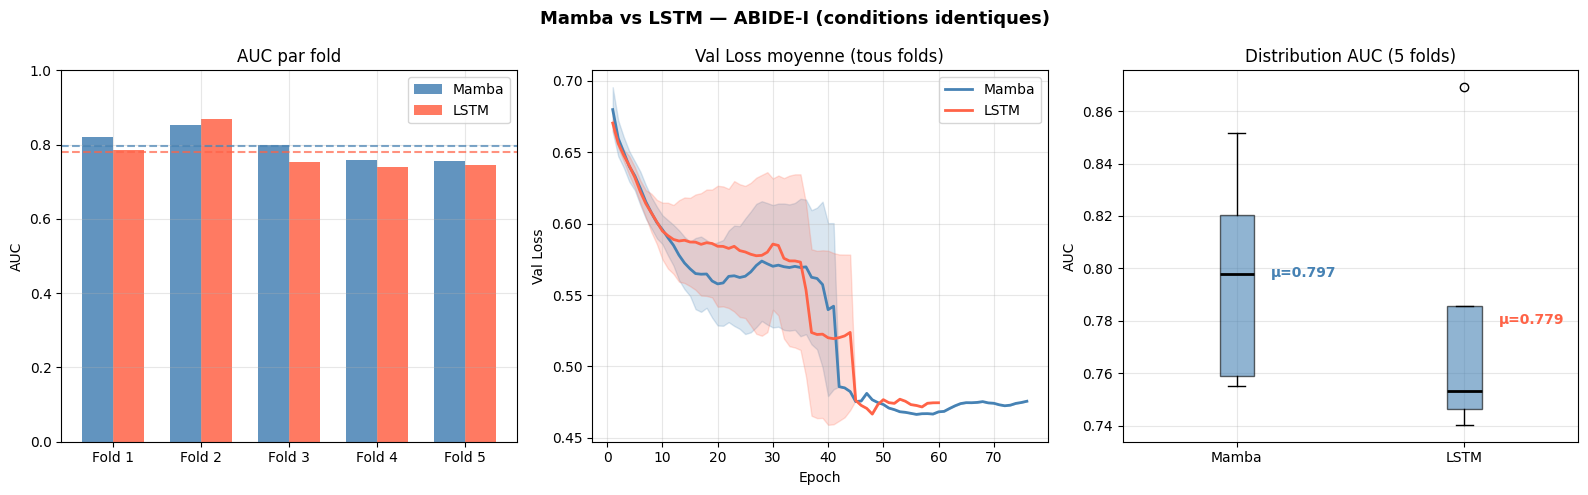

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  1. AUC par fold (barres groupées)
x     = np.arange(CONFIG['n_folds'])
width = 0.35
axes[0].bar(x - width/2, aucs_mamba, width, label='Mamba', color='steelblue',  alpha=0.85)
axes[0].bar(x + width/2, aucs_lstm,  width, label='LSTM',  color='tomato',     alpha=0.85)
axes[0].axhline(m_mean, color='steelblue', linestyle='--', lw=1.5, alpha=0.7)
axes[0].axhline(l_mean, color='tomato',    linestyle='--', lw=1.5, alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Fold {i+1}' for i in range(CONFIG['n_folds'])])
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC par fold')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

#  2. Courbes val_loss moyennes
max_len = max(len(r['history']['val_loss']) for r in results)

def pad_mean(res_list, key, max_len):
    arr = np.full((len(res_list), max_len), np.nan)
    for i, r in enumerate(res_list):
        v = r['history'][key]
        arr[i, :len(v)] = v
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

m_loss_mean, m_loss_std = pad_mean(results,      'val_loss', max_len)
l_loss_mean, l_loss_std = pad_mean(results_lstm, 'val_loss', max_len)
epochs_range = np.arange(1, max_len + 1)

axes[1].plot(epochs_range, m_loss_mean, color='steelblue', lw=2, label='Mamba')
axes[1].fill_between(epochs_range,
                      m_loss_mean - m_loss_std,
                      m_loss_mean + m_loss_std,
                      alpha=0.2, color='steelblue')
axes[1].plot(epochs_range, l_loss_mean, color='tomato', lw=2, label='LSTM')
axes[1].fill_between(epochs_range,
                      l_loss_mean - l_loss_std,
                      l_loss_mean + l_loss_std,
                      alpha=0.2, color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Val Loss moyenne (tous folds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#  3. Résumé AUC
axes[2].boxplot([aucs_mamba, aucs_lstm],
                labels=['Mamba', 'LSTM'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', lw=2))
axes[2].set_ylabel('AUC')
axes[2].set_title('Distribution AUC (5 folds)')
axes[2].grid(True, alpha=0.3)

# Annoter la moyenne
for x_pos, vals, color in zip([1, 2], [aucs_mamba, aucs_lstm], ['steelblue', 'tomato']):
    axes[2].annotate(f'μ={np.mean(vals):.3f}',
                     xy=(x_pos, np.mean(vals)),
                     xytext=(x_pos + 0.15, np.mean(vals)),
                     color=color, fontweight='bold', fontsize=10)

plt.suptitle('Mamba vs LSTM — ABIDE-I (conditions identiques)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 11.5 Architecture du modèle TransformerFMRI pour la classification ASD/Control




In [ ]:
class TransformerFMRI(nn.Module):
    """
    Transformer encoder pour classification ASD/Control sur fMRI.
    Comparable à MambaFMRI et LSTMFMRI :
    - Même input  : (B, T, n_rois)
    - Même output : logits (B, 2)
    - Même pooling temporel (mean + max)
    - Même classifieur MLP
    - Même régularisation (Dropout, DropPath via stochastic depth)


    """
    def __init__(self, n_rois=200, d_model=32, n_heads=4, n_layers=2,
                 dropout=0.5, drop_path_rate=0.2, n_classes=2, conn_dim=0):
        super().__init__()
        self.use_conn = conn_dim > 0

        # Projection initiale identique à Mamba et LSTM
        self.input_proj = nn.Sequential(
            nn.Linear(n_rois, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        # Encodage positionnel appris
        self.pos_embedding = nn.Parameter(torch.zeros(1, 200, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        # Blocs Transformer avec DropPath schedule linéaire
        dp_rates = [drop_path_rate * i / max(n_layers - 1, 1) for i in range(n_layers)]
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm1': nn.LayerNorm(d_model),
                'attn' : nn.MultiheadAttention(
                    embed_dim=d_model, num_heads=n_heads,
                    dropout=dropout * 0.5, batch_first=True
                ),
                'norm2': nn.LayerNorm(d_model),
                'ffn'  : nn.Sequential(
                    nn.Linear(d_model, d_model * 4),
                    nn.GELU(),
                    nn.Dropout(dropout * 0.5),
                    nn.Linear(d_model * 4, d_model),
                ),
                'drop_path': DropPath(dp_rates[i]),
            })
            for i in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

        if self.use_conn:
            self.conn_encoder = nn.Sequential(
                nn.Linear(conn_dim, d_model * 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model * 2, d_model),
                nn.LayerNorm(d_model),
            )

        head_in = d_model * 2 + (d_model if self.use_conn else 0)
        self.classifier = nn.Sequential(
            nn.Linear(head_in, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x, conn=None):
        B, T, _ = x.shape
        h = self.input_proj(x)
        h = h + self.pos_embedding[:, :T, :]

        for layer in self.layers:
            # Self-attention avec résidu + DropPath
            h_norm = layer['norm1'](h)
            attn_out, _ = layer['attn'](h_norm, h_norm, h_norm)
            h = h + layer['drop_path'](attn_out)
            # FFN avec résidu + DropPath
            h = h + layer['drop_path'](layer['ffn'](layer['norm2'](h)))

        h = self.final_norm(h)
        h = self.dropout(h)

        # Même pooling que Mamba et LSTM
        feat = torch.cat([h.mean(dim=1), h.max(dim=1).values], dim=-1)

        if self.use_conn and conn is not None:
            feat = torch.cat([feat, self.conn_encoder(conn)], dim=-1)

        return self.classifier(feat)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Vérification + comparaison nombre de paramètres
tf_test = TransformerFMRI(n_rois=N_ROIS, d_model=32, n_heads=4, n_layers=2)
out_tf  = tf_test(torch.randn(2, SEQ_LEN, N_ROIS))
print(f"TransformerFMRI OK  |  Paramètres : {tf_test.count_params():,}")
print(f"LSTMFMRI            |  Paramètres : {LSTMFMRI(n_rois=N_ROIS, d_model=32, n_layers=2).count_params():,}")
print(f"MambaFMRI           |  Paramètres : {MambaFMRI(n_rois=N_ROIS, d_model=32, n_layers=2).count_params():,}")
print(f"Output shape : {out_tf.shape}")


TransformerFMRI OK  |  Paramètres : 40,514
LSTMFMRI            |  Paramètres : 21,506
MambaFMRI           |  Paramètres : 29,090
Output shape : torch.Size([2, 2])


### 11.6 Entraînement Transformer (mêmes conditions)

In [ ]:
#  Même CONFIG, même split, même boucle que Mamba et LSTM
results_tf = []

for fold, (train_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=42
    ).split(X_seq, y)
):
    print(f"\n{'='*50}")
    print(f"  Transformer — Fold {fold+1}/{CONFIG['n_folds']}")
    print(f"{'='*50}")

    X_tr, X_val = X_seq[train_idx], X_seq[val_idx]
    y_tr, y_val = y[train_idx],     y[val_idx]
    c_tr, c_val = conn_vectors[train_idx], conn_vectors[val_idx]

    scaler = StandardScaler()
    c_tr   = scaler.fit_transform(c_tr).astype(np.float32)
    c_val  = scaler.transform(c_val).astype(np.float32)

    conn_dim = c_tr.shape[1] if CONFIG['use_conn'] else 0

    train_ds = ABIDEDataset(X_tr, y_tr, c_tr if CONFIG['use_conn'] else None, augment=True)
    val_ds   = ABIDEDataset(X_val, y_val, c_val if CONFIG['use_conn'] else None, augment=False)
    train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False)

    model_tf = TransformerFMRI(
        n_rois         = N_ROIS,
        d_model        = CONFIG['d_model'],
        n_heads        = 4,
        n_layers       = CONFIG['n_layers'],
        dropout        = CONFIG['dropout'],
        drop_path_rate = CONFIG['drop_path_rate'],
        conn_dim       = conn_dim,
    ).to(DEVICE)

    class_counts  = np.bincount(y_tr)
    class_weights = torch.tensor(1. / class_counts, dtype=torch.float32).to(DEVICE)

    criterion_smooth = nn.CrossEntropyLoss(weight=class_weights,
                                           label_smoothing=CONFIG['label_smoothing'])
    criterion_hard   = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model_tf.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
       optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7
    )

    best_val_loss = float('inf')
    best_val_auc  = 0.
    best_state    = None
    no_improve    = 0
    history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

    for epoch in range(CONFIG['n_epochs']):
        tr_loss, tr_acc            = train_epoch(model_tf, train_dl, optimizer,
                                                  criterion_smooth, DEVICE,
                                                  use_mixup=True,
                                                  mixup_alpha=CONFIG['mixup_alpha'])
        val_loss, val_acc, val_auc = eval_epoch(model_tf, val_dl, criterion_hard, DEVICE)
        scheduler.step(val_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_auc  = val_auc
            best_state    = {k: v.cpu().clone() for k, v in model_tf.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Train {tr_loss:.3f} ({tr_acc:.2f}) | "
                  f"Val {val_loss:.3f} ({val_acc:.2f}) AUC {val_auc:.3f} | "
                  f"patience {no_improve}/{CONFIG['patience']}")

        if no_improve >= CONFIG['patience']:
            print(f"  Early stopping epoch {epoch+1}")
            break

    results_tf.append({'fold': fold+1, 'best_auc': best_val_auc,
                       'best_val_loss': best_val_loss,
                       'history': history, 'best_state': best_state})
    print(f"  -> Best val_loss {best_val_loss:.4f}  |  Best AUC {best_val_auc:.3f}")

aucs_tf = [r['best_auc'] for r in results_tf]
print(f"\nTransformer — AUC : {np.mean(aucs_tf):.3f} +/- {np.std(aucs_tf):.3f}")
print(f"LSTM        — AUC : {np.mean(aucs_lstm):.3f} +/- {np.std(aucs_lstm):.3f}")
print(f"Mamba       — AUC : {np.mean(aucs_mamba):.3f} +/- {np.std(aucs_mamba):.3f}")



  Transformer — Fold 1/5
  Epoch  10 | Train 0.525 (0.88) | Val 0.592 (0.72) AUC 0.772 | patience 0/20
  Epoch  20 | Train 0.463 (0.98) | Val 0.575 (0.70) AUC 0.788 | patience 5/20
  Epoch  30 | Train 0.418 (1.00) | Val 0.586 (0.73) AUC 0.791 | patience 15/20
  Early stopping epoch 35
  -> Best val_loss 0.5660  |  Best AUC 0.803

  Transformer — Fold 2/5
  Epoch  10 | Train 0.522 (0.83) | Val 0.569 (0.75) AUC 0.810 | patience 0/20
  Epoch  20 | Train 0.412 (0.98) | Val 0.504 (0.79) AUC 0.833 | patience 1/20
  Epoch  30 | Train 0.382 (0.99) | Val 0.509 (0.77) AUC 0.830 | patience 2/20
  Epoch  40 | Train 0.462 (1.00) | Val 0.500 (0.79) AUC 0.838 | patience 12/20
  Early stopping epoch 48
  -> Best val_loss 0.4949  |  Best AUC 0.836

  Transformer — Fold 3/5
  Epoch  10 | Train 0.520 (0.88) | Val 0.583 (0.71) AUC 0.782 | patience 0/20
  Epoch  20 | Train 0.438 (0.98) | Val 0.594 (0.68) AUC 0.767 | patience 6/20
  Epoch  30 | Train 0.429 (1.00) | Val 0.607 (0.69) AUC 0.765 | patience 16/

### 11.7 Tableau comparatif Mamba vs LSTM vs Transformer

In [ ]:
#  Tableau par fold
aucs_mamba = [r['best_auc'] for r in results]
aucs_lstm  = [r['best_auc'] for r in results_lstm]
aucs_tf    = [r['best_auc'] for r in results_tf]

print(f"{'Fold':<6} {'Mamba':>8} {'LSTM':>8} {'Transfo':>8} {'Best':>10}")
print("-" * 48)
for i in range(CONFIG['n_folds']):
    m, l, t = aucs_mamba[i], aucs_lstm[i], aucs_tf[i]
    best = ['Mamba', 'LSTM', 'Transfo'][np.argmax([m, l, t])]
    print(f"  {i+1:<4} {m:>8.4f} {l:>8.4f} {t:>8.4f} {best:>10}")
print("-" * 48)
print(f"  {'Moy':<4} {np.mean(aucs_mamba):>8.4f} {np.mean(aucs_lstm):>8.4f} {np.mean(aucs_tf):>8.4f}")
print(f"  {'Std':<4} {np.std(aucs_mamba):>8.4f} {np.std(aucs_lstm):>8.4f} {np.std(aucs_tf):>8.4f}")
print()

#  Nombre de paramètres
n_mamba = MambaFMRI(n_rois=N_ROIS, d_model=CONFIG['d_model'],
                    n_layers=CONFIG['n_layers']).count_params()
n_lstm  = LSTMFMRI(n_rois=N_ROIS, d_model=CONFIG['d_model'],
                   n_layers=CONFIG['n_layers']).count_params()
n_tf    = TransformerFMRI(n_rois=N_ROIS, d_model=CONFIG['d_model'],
                          n_layers=CONFIG['n_layers'], n_heads=4).count_params()

print(f"Paramètres — Mamba : {n_mamba:>8,}")
print(f"Paramètres — LSTM  : {n_lstm:>8,}")
print(f"Paramètres — Transfo:{n_tf:>8,}")


Fold      Mamba     LSTM  Transfo       Best
------------------------------------------------
  1      0.8205   0.7856   0.8032      Mamba
  2      0.8518   0.8691   0.8364       LSTM
  3      0.7979   0.7534   0.7761      Mamba
  4      0.7589   0.7403   0.7693    Transfo
  5      0.7550   0.7463   0.7527      Mamba
------------------------------------------------
  Moy    0.7968   0.7789   0.7875
  Std    0.0368   0.0477   0.0294

Paramètres — Mamba :   29,090
Paramètres — LSTM  :   21,506
Paramètres — Transfo:  40,514


### 11.8 Visualisation finale — comparaison des trois modèles

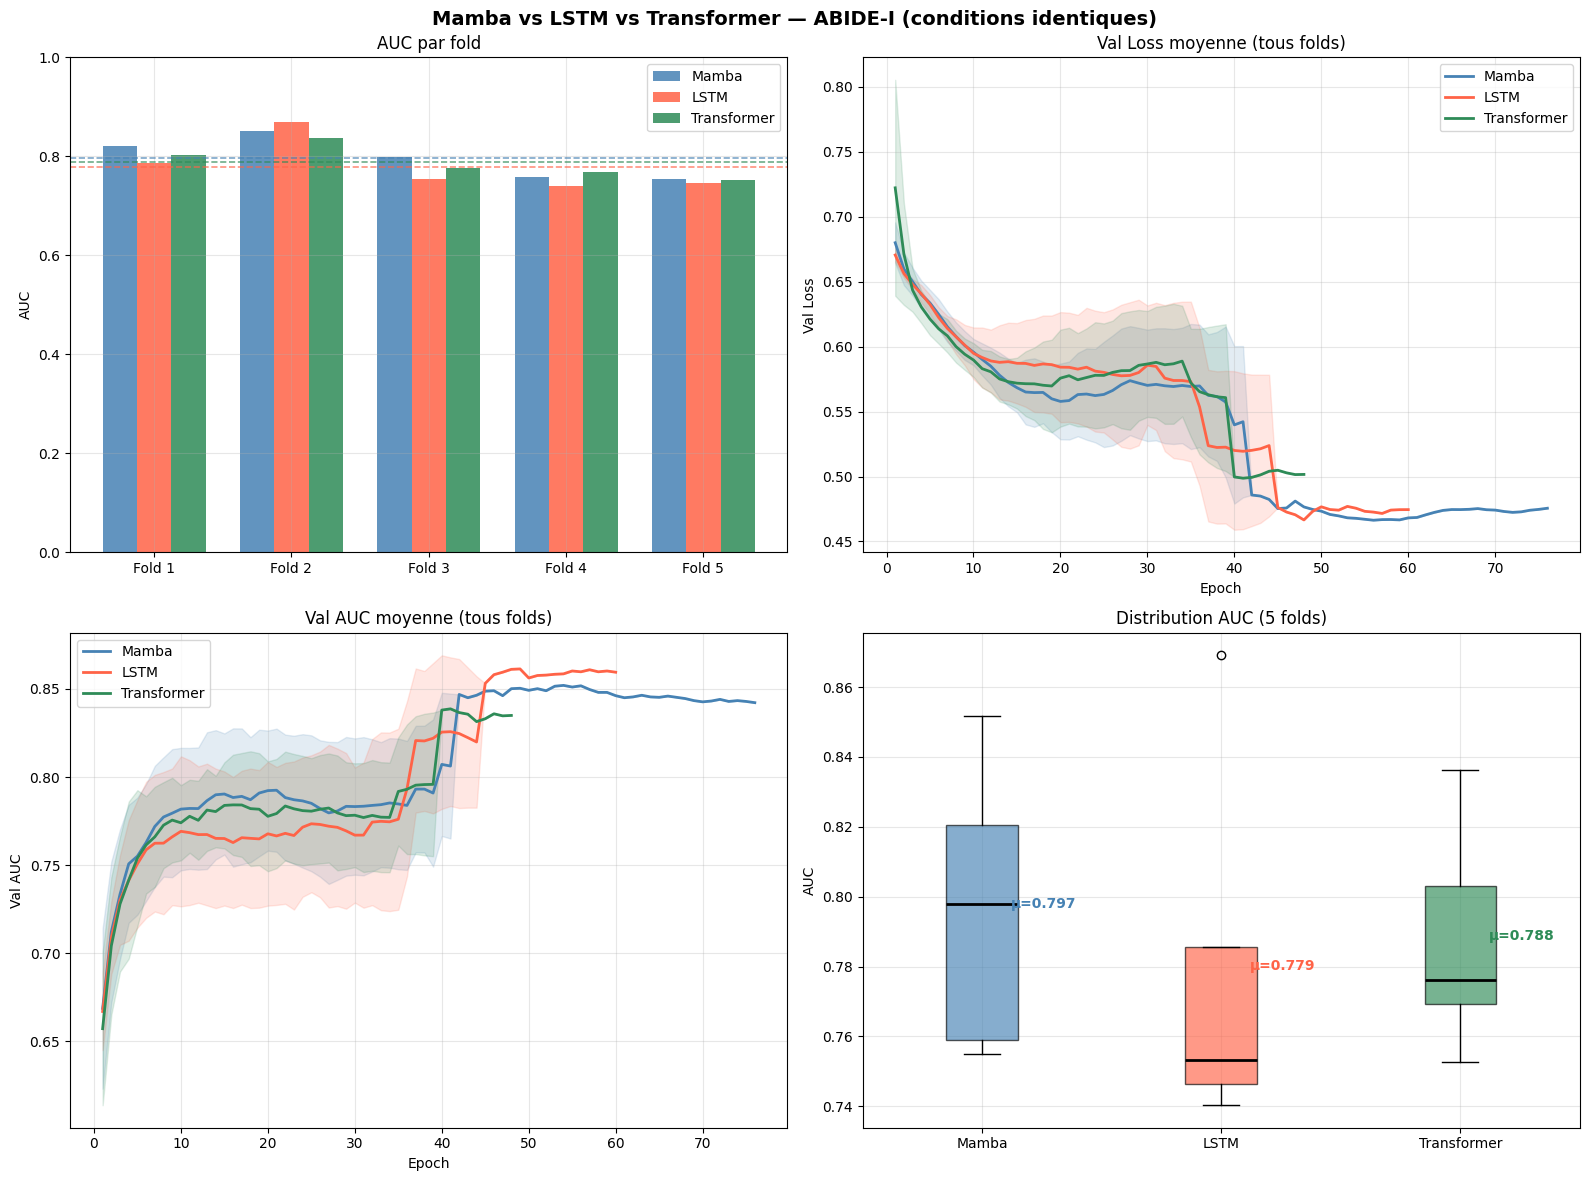


  Résumé final
  Mamba        AUC = 0.7968 ± 0.0368
  LSTM         AUC = 0.7789 ± 0.0477
  Transformer  AUC = 0.7875 ± 0.0294

  Meilleur modèle : Mamba


In [ ]:
COLORS = {'Mamba': 'steelblue', 'LSTM': 'tomato', 'Transformer': 'seagreen'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#  1. AUC par fold
x     = np.arange(CONFIG['n_folds'])
width = 0.25
axes[0,0].bar(x - width, aucs_mamba, width, label='Mamba',       color=COLORS['Mamba'],       alpha=0.85)
axes[0,0].bar(x,          aucs_lstm,  width, label='LSTM',        color=COLORS['LSTM'],        alpha=0.85)
axes[0,0].bar(x + width,  aucs_tf,   width, label='Transformer', color=COLORS['Transformer'], alpha=0.85)
for vals, color in zip([aucs_mamba, aucs_lstm, aucs_tf], COLORS.values()):
    axes[0,0].axhline(np.mean(vals), color=color, linestyle='--', lw=1.2, alpha=0.7)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels([f'Fold {i+1}' for i in range(CONFIG['n_folds'])])
axes[0,0].set_ylabel('AUC')
axes[0,0].set_title('AUC par fold')
axes[0,0].legend()
axes[0,0].set_ylim(0, 1)
axes[0,0].grid(True, alpha=0.3)

#  2. Val Loss moyenne par epoch
def pad_mean(res_list, key):
    max_len = max(len(r['history'][key]) for r in res_list)
    arr = np.full((len(res_list), max_len), np.nan)
    for i, r in enumerate(res_list):
        v = r['history'][key]
        arr[i, :len(v)] = v
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0), max_len

for res_list, label in zip([results, results_lstm, results_tf],
                            ['Mamba', 'LSTM', 'Transformer']):
    mean, std, mlen = pad_mean(res_list, 'val_loss')
    ep = np.arange(1, mlen + 1)
    axes[0,1].plot(ep, mean, color=COLORS[label], lw=2, label=label)
    axes[0,1].fill_between(ep, mean - std, mean + std,
                            alpha=0.15, color=COLORS[label])
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Val Loss')
axes[0,1].set_title('Val Loss moyenne (tous folds)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

#  3. Val AUC moyenne par epoch
for res_list, label in zip([results, results_lstm, results_tf],
                            ['Mamba', 'LSTM', 'Transformer']):
    mean, std, mlen = pad_mean(res_list, 'val_auc')
    ep = np.arange(1, mlen + 1)
    axes[1,0].plot(ep, mean, color=COLORS[label], lw=2, label=label)
    axes[1,0].fill_between(ep, mean - std, mean + std,
                            alpha=0.15, color=COLORS[label])
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Val AUC')
axes[1,0].set_title('Val AUC moyenne (tous folds)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

#  4. Boîte à moustaches AUC
bp = axes[1,1].boxplot(
    [aucs_mamba, aucs_lstm, aucs_tf],
    labels=['Mamba', 'LSTM', 'Transformer'],
    patch_artist=True,
    medianprops=dict(color='black', lw=2)
)
for patch, color in zip(bp['boxes'], COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

# Annoter la moyenne
for x_pos, vals, color in zip([1, 2, 3],
                                [aucs_mamba, aucs_lstm, aucs_tf],
                                COLORS.values()):
    axes[1,1].annotate(f'μ={np.mean(vals):.3f}',
                        xy=(x_pos, np.mean(vals)),
                        xytext=(x_pos + 0.12, np.mean(vals)),
                        color=color, fontweight='bold', fontsize=10)

axes[1,1].set_ylabel('AUC')
axes[1,1].set_title('Distribution AUC (5 folds)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Mamba vs LSTM vs Transformer — ABIDE-I (conditions identiques)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  Résumé final
print("\n" + "="*52)
print("  Résumé final")
print("="*52)
for label, aucs in zip(['Mamba', 'LSTM', 'Transformer'],
                        [aucs_mamba, aucs_lstm, aucs_tf]):
    print(f"  {label:<12} AUC = {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
winner = ['Mamba', 'LSTM', 'Transformer'][np.argmax([np.mean(aucs_mamba),
                                                       np.mean(aucs_lstm),
                                                       np.mean(aucs_tf)])]
print(f"\n  Meilleur modèle : {winner}")
print("="*52)
